In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal, List
import os
from langchain_openai import ChatOpenAI
# from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage
load_dotenv()

True

In [17]:
model = ChatGroq(model="llama-3.1-8b-instant", api_key=os.getenv("GROQ_API_KEY"), temperature=0.4,max_tokens=150)#type:ignore

In [5]:
class State(TypedDict):
    topic : str
    joke : str
    exp : str

In [18]:
def get_joke(state:State):
    prompt = f"Generate a joke on topic {state['topic']}"
    res = model.invoke(prompt).content
    return {'joke':res}

In [19]:
def get_explanation(state:State):
    prompt = f"Generate a explanation on the provided joke {state['joke']}"
    res = model.invoke(prompt).content
    return {'exp':res}

In [9]:
from langgraph.checkpoint.memory import InMemorySaver

In [20]:
checkpointer = InMemorySaver()
graph = StateGraph(State)

graph.add_node("get_joke",get_joke)
graph.add_node("get_explanation",get_explanation)

graph.add_edge(START,"get_joke")
graph.add_edge("get_joke","get_explanation")
graph.add_edge("get_explanation",END)

workflow = graph.compile(checkpointer=checkpointer)

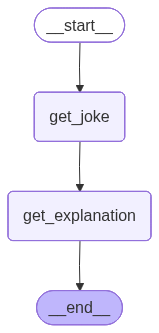

In [11]:
workflow

In [21]:
config = {'configurable':{'thread_id':'1'}}
input_state = {'topic':'pizza'}
output_state = workflow.invoke(input_state,config=config) # type:ignore

In [22]:
output_state

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor?\n\nBecause it was feeling a little crusty.',
 'exp': 'The joke "Why did the pizza go to the doctor? Because it was feeling a little crusty" is a play on words. It uses a pun to create humor.\n\nIn this joke, "crusty" has a double meaning. \n\n1. A pizza crust is the outer layer of a pizza, which is typically crispy and crunchy. \n2. "Feeling a little crusty" is also an idiom that means to feel a bit grumpy or irritable.\n\nBy combining these two meanings, the joke creates a clever and humorous connection between the pizza\'s physical characteristic (crust) and its emotional state (feeling crusty). The wordplay creates a lighthearted and amusing effect, making the joke enjoyable to'}

In [23]:
list(workflow.get_state_history(config=config))#type:ignore

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\n\nBecause it was feeling a little crusty.', 'exp': 'The joke "Why did the pizza go to the doctor? Because it was feeling a little crusty" is a play on words. It uses a pun to create humor.\n\nIn this joke, "crusty" has a double meaning. \n\n1. A pizza crust is the outer layer of a pizza, which is typically crispy and crunchy. \n2. "Feeling a little crusty" is also an idiom that means to feel a bit grumpy or irritable.\n\nBy combining these two meanings, the joke creates a clever and humorous connection between the pizza\'s physical characteristic (crust) and its emotional state (feeling crusty). The wordplay creates a lighthearted and amusing effect, making the joke enjoyable to'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f181f19-4dff-6321-8002-4af41b9f787b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-17T15:10:01.000

In [24]:
config2 = {'configurable':{'thread_id':'2'}}
input_state = {'topic':'pasta'}
output_state = workflow.invoke(input_state,config=config2) # type:ignore

In [25]:
output_state

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "twisted."',
 'exp': 'This joke is a play on words, which is a common technique used in humor. The punchline "feeling a little \'twisted\'" has a double meaning:\n\n1. In a literal sense, spaghetti is a type of pasta that is twisted or curved in shape. So, the joke is making a pun on the physical characteristic of spaghetti.\n2. In a figurative sense, "twisted" can also mean feeling emotionally disturbed or having mental health issues. This is the meaning implied by the setup "Why did the spaghetti go to therapy?"\n\nThe joke relies on the unexpected twist (pun intended) of the word "twisted" having two different meanings, creating a clever and amusing connection between the setup and the punchline. This type'}

In [29]:
list(workflow.get_state_history(config=config2))#type:ignore

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy? \n\nBecause it was feeling a little "twisted."', 'exp': 'This joke is a play on words, which is a common technique used in humor. The punchline "feeling a little \'twisted\'" has a double meaning:\n\n1. In a literal sense, spaghetti is a type of pasta that is twisted or curved in shape. So, the joke is making a pun on the physical characteristic of spaghetti.\n2. In a figurative sense, "twisted" can also mean feeling emotionally disturbed or having mental health issues. This is the meaning implied by the setup "Why did the spaghetti go to therapy?"\n\nThe joke relies on the unexpected twist (pun intended) of the word "twisted" having two different meanings, creating a clever and amusing connection between the setup and the punchline. This type'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f181f1e-4334-6d19-8002-96de5bdcb1f5'}}, metadata={'source': 'loo